# Historgrams of image data

### Exercises

81 items to plot


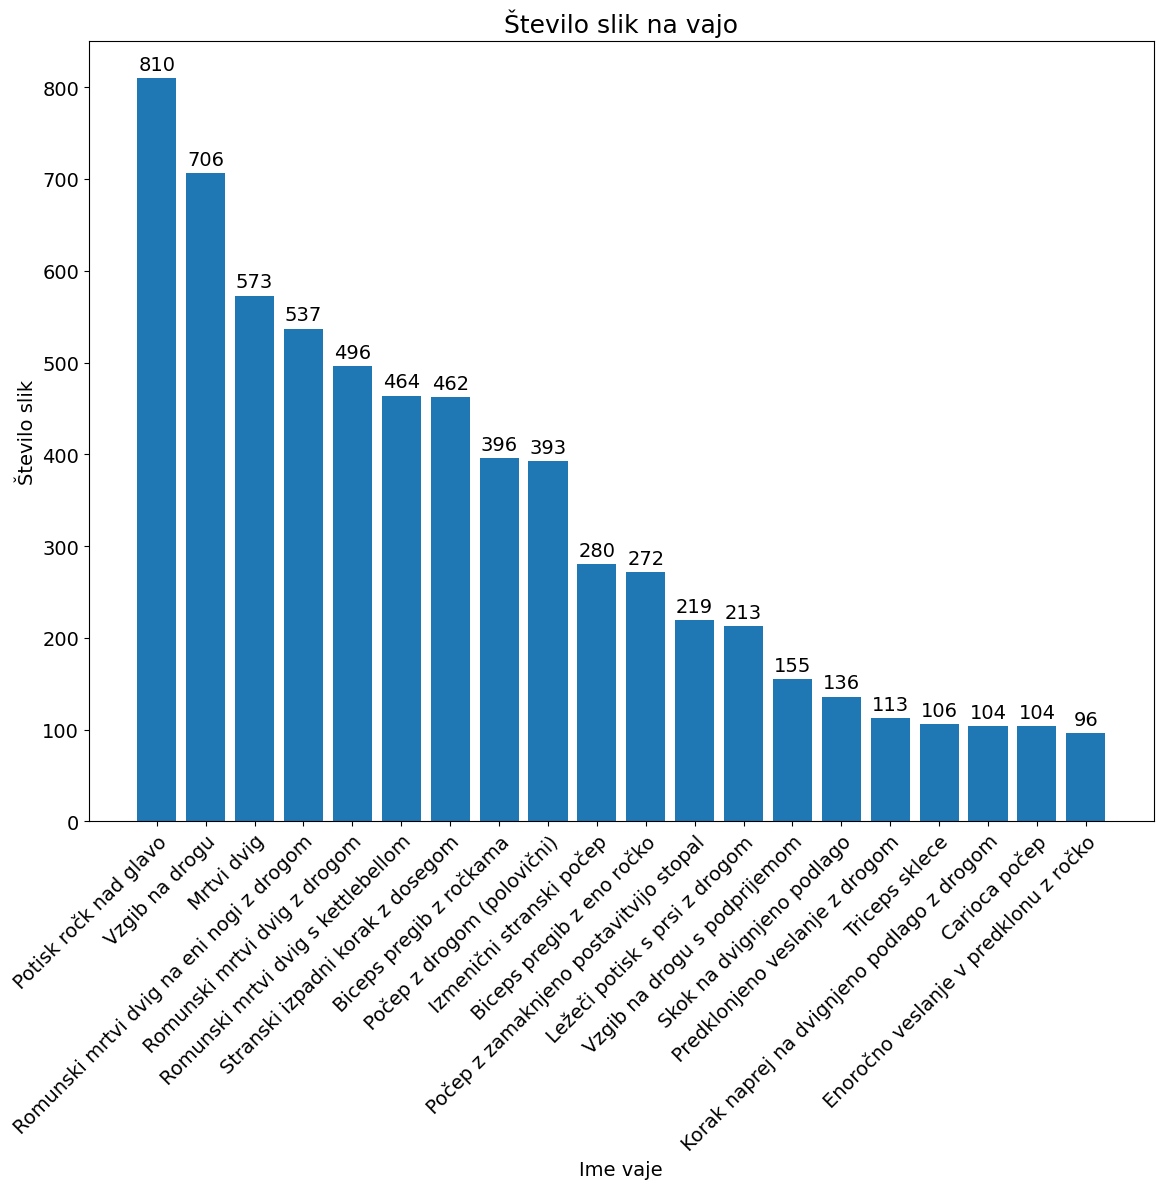

134 items to plot


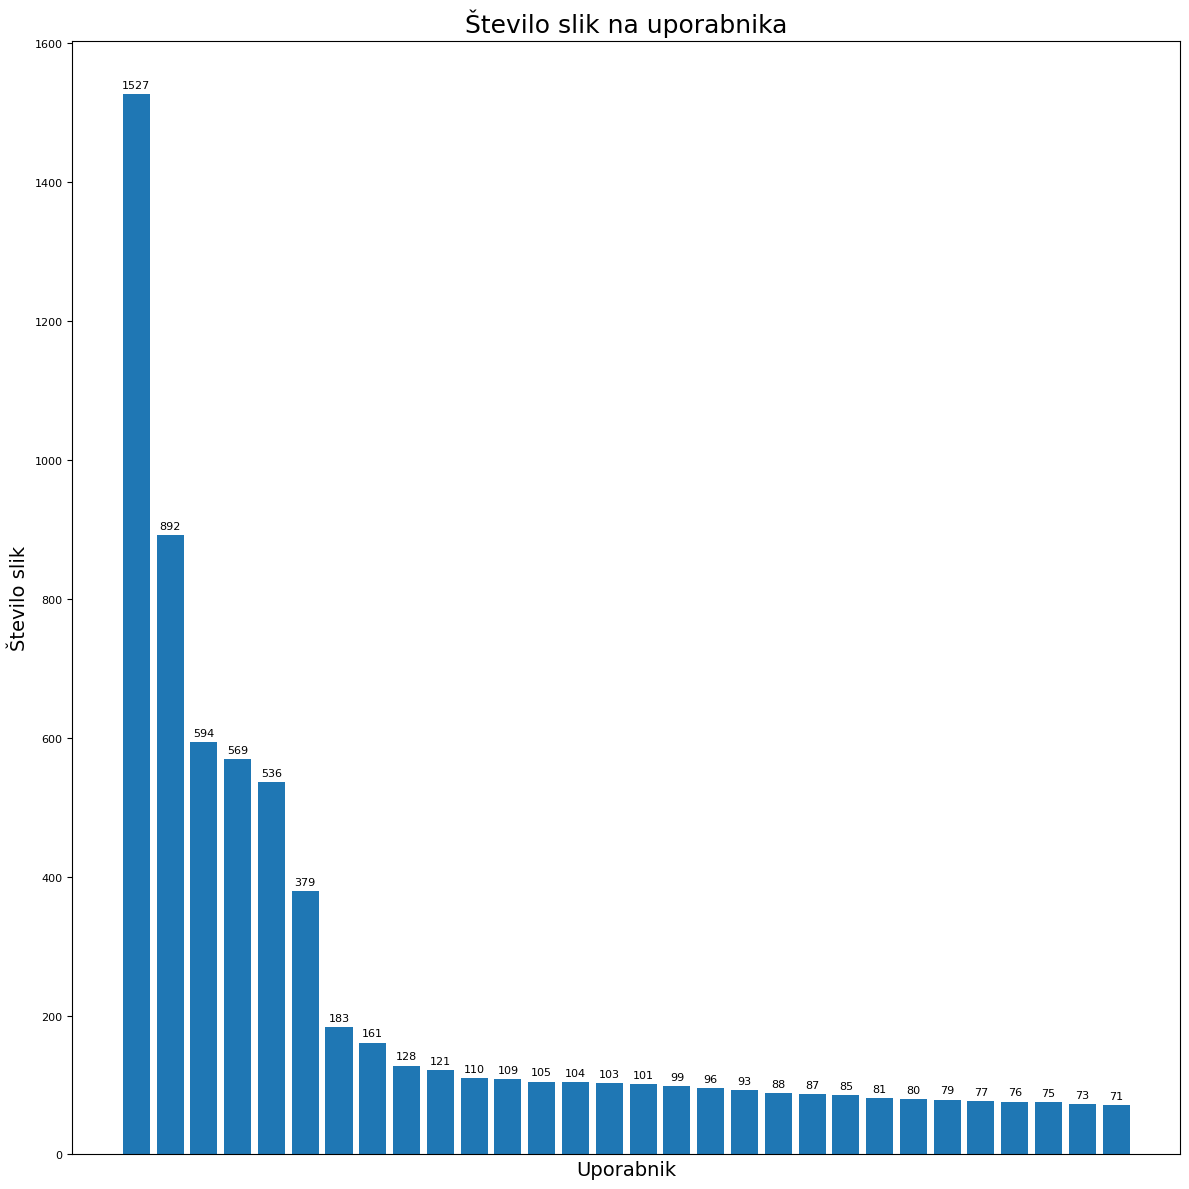

Counter({'01Cz04ye3OOIktLB2NPOGHFC2rs2': 1527, 'dnu0HfSmrSUp0tvYrW9zzTMhQnP2': 892, 'dV4sk5CZeNOXBXZ4QAiZWmsuckn1': 594, 'OXCamd6fqUduaV4SZhCL2WvToas1': 569, 'BMAnhivW3YMrDFehtSii2h9Csqs2': 536, 'RFOAsKxwfHeeNlD4OnYCy53aOPi1': 379, '39d46945-7d5a-44c9-876d-44e8b76c3ce7': 183, 'gSm8IxWEt4cDHpI7V8EodSQ6au82': 161, 'b5L2Ht4z3WeQQIdh8Wa0zriVhAg2': 128, 'l1EgHsqFvJbSO0v4KgIKsYZgojd2': 121, 'ewrYvw30KxN57mzBCfUnru6eYIC2': 110, 'wo413g3HTlbBTVuriDpEG1I6Dpv2': 109, 'uX9dK9Ge2oZEDJtceOaivrnC1a32': 105, 'k5oMe8ac0cRGuD40FqRkANqIhvw2': 104, 'wdDvaQHYHoQkD8teFBzswDSxeRs1': 103, 'V6qB04OdVCetdSfbXXrzhJ7oD8t1': 101, 'nzoVbAiaQkMuDberk2sLVmqsXJJ3': 99, 'Tqg0V504CNbx4QV5sapjI8EZLfE3': 96, 'rYJ7SB1P6dMEOUxXoUxGaGHTOCV2': 93, 'XpuduP8l8jcU2boCA1sFSlhJZ3p2': 88, 'N42EF2N5D8NpBODR9ftHG13kGBY2': 87, 'raaqayP6dHVbVXQjCz2GhmLiuKH3': 85, 'PMkJ6WdRVlYOfJQ6inbbbsE4DGb2': 81, 'sprxwAbwhRZwDYSfFitOGdH4Uwd2': 80, 'ltHNohVWxKe4HLVkirPB57BdLOh2': 79, 'QJ3u1pSSV6ZIFfr7Ti9Z1UiuFRC3': 77, 'Vek2JmzUYbTlcRhj8PWzogC60B22'

In [12]:
import os
from collections import Counter
import matplotlib.pyplot as plt

image_dirs = [
    r"D:\Magistrska\blindoff-dataset\images",
    # r"D:\Magistrska\blindoff-dataset\selected_images",
]

# Collect unique filenames across both folders (dedupe overlap)
all_files = []
for d in image_dirs:
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Directory not found: {d}")
    for f in os.listdir(d):
        if f.lower().endswith(".jpg"):
            all_files.append(f)

unique_files = set(all_files)

exercise_counts = Counter()
user_counts = Counter()

bad_names = []
for fname in unique_files:
    parts = fname.split("_")
    # Expect: training_id, user_id, exercise_name, set_number, rep_number(.jpg)
    if len(parts) != 5 or not parts[-1].lower().endswith(".jpg"):
        bad_names.append(fname)
        continue

    training_id, user_id, exercise_name, set_number, rep_number = parts

    if len(exercise_name.split("-")[-1]) > 10:
        exercise_name = exercise_name.rsplit("-", 1)[0]

    exercise_counts[exercise_name] += 1
    user_counts[user_id] += 1

if bad_names:
    print(f"Skipped {len(bad_names)} files due to unexpected naming.")
    print("Example(s):", bad_names[:5])


def exercise_name_mapper(id):
    if id == 'db-ohp':
        return "Potisk ročk nad glavo"
    elif id == 'pull-up':
        return 'Vzgib na drogu'
    elif id == 'tb-deadlift':
        return 'Mrtvi dvig'
    elif id == 'bb-sl-rdl':
        return 'Romunski mrtvi dvig na eni nogi z drogom'
    elif id == 'rdl-bb':
        return 'Romunski mrtvi dvig z drogom'
    elif id == 'rdl-kb':
        return 'Romunski mrtvi dvig s kettlebellom'
    elif id == 'lateral-lunge-pl-reach':
        return 'Stranski izpadni korak z dosegom'
    elif id == 'biceps-curl-db':
        return 'Biceps pregib z ročkama'
    elif id == 'bb-back-squat-[half]':
        return 'Počep z drogom (polovični)'
    elif id == 'lm-hang-alt-lateral-squat':
        return 'Izmenični stranski počep'
    elif id == 'biceps-curl-sa-db':
        return 'Biceps pregib z eno ročko'
    elif id == 'bb-staggered-squat-[quarter]':
        return 'Počep z zamaknjeno postavitvijo stopal'
    elif id == 'bench-press-bb':
        return 'Ležeči potisk s prsi z drogom'
    elif id == 'deep-back-squat-bb':
        return 'Globoki počep z drogom (globoki)'
    elif id == 'chin-up':
        return 'Vzgib na drogu s podprijemom'
    elif id == 'step-up-jump':
        return 'Skok na dvignjeno podlago'
    elif id == 'bb-bent-over-row':
        return 'Predklonjeno veslanje z drogom'
    elif id == 'triceps-dips':
        return 'Triceps sklece'
    elif id == 'bb-forward-step-up':
        return 'Korak naprej na dvignjeno podlago z drogom'
    elif id == 'carioca-squat':
        return 'Carioca počep'
    elif id == 'db-sa-bent-over-row':
        return 'Enoročno veslanje v predklonu z ročko'
    
    return id


def plot_counter_sorted(
    counter, title, xlabel, ylabel, top_n=None, tick_fontsize=8, disable_x_ticks=False, rotation=45,
):
    print(len(counter), "items to plot")
    items = counter.most_common(top_n)  # sorted desc by count
    labels = [k for k, _ in items]
    values = [v for _, v in items]

    fig, ax = plt.subplots(figsize=(12, 12))
    bars = ax.bar(labels, values)
    ax.bar_label(
        bars,
        labels=[str(value) for value in values],
        padding=3,
        fontsize=tick_fontsize,
    )
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    if disable_x_ticks:
        ax.set_xticks([])
    else:
        plt.xticks(rotation=90, fontsize=tick_fontsize)
        plt.setp(
            ax.get_xticklabels(),
            rotation=rotation,
            ha="right" if rotation else "center",
            rotation_mode="anchor",
        )


    ax.tick_params(axis="y", labelsize=tick_fontsize)
    fig.tight_layout()
    plt.show()

skip_ids = ['db-biceps-curl', 'deep-back-squat-bb', 'half-back-squat-bb', 'db-sa-biceps-curl', 'shoulder-press-db', 'bent-over-row-bb']

exercise_counts = Counter({exercise_name_mapper(k): v for k, v in exercise_counts.items() if k not in skip_ids})

# Plot 1: images per exercise (sorted)
plot_counter_sorted(
    exercise_counts,
    title="Število slik na vajo",
    xlabel="Ime vaje",
    ylabel="Število slik",
    top_n=20,  # set e.g. 30 if too crowded
    tick_fontsize=14,
)

# Plot 2: images per user (sorted)
plot_counter_sorted(
    user_counts,
    title="Število slik na uporabnika",
    xlabel="Uporabnik",
    ylabel="Število slik",
    top_n=30,  # bump higher / None if you want all
    tick_fontsize=8,
    disable_x_ticks=True,
)

print(user_counts)